# Trabajo Práctico: Predicción de precios de casas

**Aprendizaje Automático 1 — Tecnicatura Universitaria en Inteligencia Artificial (FCEIA - UNR)**

**Integrantes:** Franco Esparza, Franco Renna, Leandro Picó

**Objetivo:** predecir `MEDV` (valor mediano de las viviendas de cada barrio de Boston, en miles de dólares) a partir de 13 características del barrio.

### Contenidos
1. Configuración
2. Carga de datos
3. Datos faltantes y consistencia
4. Limpieza previa al split
5. División train / validación / test
6. Análisis descriptivo
7. Relación con el target y correlación
8. Codificación de variables categóricas
9. Imputación de faltantes
10. Escalado

---
## 1. Configuración

In [1]:
# Importación de librerías y configuración global de gráficos y de pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Configuracion global de visualizacion
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='viridis')

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga de datos

El target `MEDV` es un número continuo, así que el problema es de **regresión**. Las 13 variables explicativas se describen en la sección 6.

In [2]:
# Carga del dataset y definicion del target y de las variables explicativas
df = pd.read_csv('house-prices-tp.csv')

TARGET = 'MEDV'
cols_features = [c for c in df.columns if c != TARGET]

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000


---
## 3. Datos faltantes y consistencia

Se analiza sobre todo el dataset porque acá solo se cuenta: no se calcula nada que después se use en el modelo.

In [3]:
# Reporte de valores nulos por columna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23          4.1367  float64
ZN          22          3.9568  float64
INDUS       15          2.6978  float64
CHAS        23          4.1367  float64
NOX         24          4.3165  float64
RM          21          3.7770  float64
AGE         24          4.3165  float64
DIS         15          2.6978  float64
RAD         28          5.0360  float64
TAX         18          3.2374  float64
PTRATIO     28          5.0360  float64
B           22          3.9568  float64
LSTAT       22          3.9568  float64
MEDV        21          3.7770  float64

Total de celdas con nulos: 306 (3.9311% del dataset)


Todas las columnas tienen entre 2,7% y 5% de faltantes, incluido el target. Veamos cómo se reparten entre las filas.

In [4]:
# Faltantes por fila: ¿estan repartidos en muchas filas o concentrados en pocas?
nulos_por_fila = df.isna().sum(axis=1)
p_faltante = df.isna().mean().mean()
filas_esperadas = len(df) * (1 - (1 - p_faltante) ** df.shape[1])  # si faltaran al azar e independientes

print(f'Filas completas: {(nulos_por_fila == 0).sum()}')
print(f'Filas con al menos un faltante: {(nulos_por_fila > 0).sum()} ({(nulos_por_fila > 0).mean() * 100:.2f}%)')
print(f'Filas incompletas esperadas si los faltantes fueran al azar: {filas_esperadas:.0f}')

Filas completas: 506
Filas con al menos un faltante: 50 (8.99%)
Filas incompletas esperadas si los faltantes fueran al azar: 239


In [5]:
# Duplicados, valores fuera del dominio posible y valores no enteros de RAD (es un indice, deberia ser entero)
rad_no_entero = df['RAD'].notna() & (df['RAD'] % 1 != 0)

print(f'Registros duplicados: {df.duplicated().sum()}')
print(f'Valores negativos: {(df < 0).sum().sum()}')
print(f'Porcentajes (ZN, INDUS, AGE, LSTAT) fuera de [0, 100]: '
      f'{((df[["ZN", "INDUS", "AGE", "LSTAT"]] < 0) | (df[["ZN", "INDUS", "AGE", "LSTAT"]] > 100)).sum().sum()}')
print(f'Valores distintos de CHAS: {sorted(df["CHAS"].dropna().unique().tolist())}')
print(f'Valores no enteros de RAD: {rad_no_entero.sum()} '
      f'(en filas completas: {(rad_no_entero & (nulos_por_fila == 0)).sum()} | '
      f'en filas con faltantes: {(rad_no_entero & (nulos_por_fila > 0)).sum()})')

Registros duplicados: 0
Valores negativos: 0
Porcentajes (ZN, INDUS, AGE, LSTAT) fuera de [0, 100]: 0
Valores distintos de CHAS: [0.0, 1.0]
Valores no enteros de RAD: 22 (en filas completas: 0 | en filas con faltantes: 22)


**Conclusiones y decisiones:**
- Los faltantes están **concentrados**: si fueran al azar habría más de 200 filas incompletas, pero hay solo **50**, y el resto (506) está completo. En la Figura 3 (sección 7) se ve además que esas 50 filas no siguen el patrón de las demás.
- **Se conservan**, porque eliminarlas sería perder el 9% de los datos. Adoptamos como criterio no descartar más del 5%. Sus faltantes se imputan en la sección 9.
- No hay duplicados ni valores fuera de rango. La única inconsistencia son los **valores no enteros de `RAD`**: es un índice, en las filas completas siempre es entero, y todos los no enteros están en las filas con faltantes.

---
## 4. Limpieza previa al split

Estas dos correcciones se deciden **fila por fila**, sin calcular nada con el resto de los datos, así que pueden hacerse antes de dividir sin fuga de información:
- **Filas sin `MEDV`:** se eliminan. Sin el valor real no sirven para entrenar ni para evaluar, e imputar el target sería inventar la respuesta. Son el 3,8%, dentro del 5%.
- **`RAD` no enteros:** se pasan a faltantes. `RAD` es un índice que solo toma ciertos valores enteros, así que un decimal no es un valor posible; en lugar de inventar uno redondeando, lo tratamos como dato ausente y lo imputamos junto con el resto (sección 9).

In [6]:
# Eliminacion de filas sin target y paso a faltante de los valores no enteros de RAD
filas_antes = df.shape[0]
df = df[df[TARGET].notna()].reset_index(drop=True)
print(f'Filas eliminadas por no tener MEDV: {filas_antes - df.shape[0]} '
      f'({(filas_antes - df.shape[0]) / filas_antes * 100:.2f}%) -> quedan {df.shape[0]}')

rad_no_entero = df['RAD'].notna() & (df['RAD'] % 1 != 0)
df.loc[rad_no_entero, 'RAD'] = np.nan
print(f'Valores de RAD pasados a faltante: {rad_no_entero.sum()}')
print(f'Celdas faltantes en las variables explicativas: {df[cols_features].isna().sum().sum()} '
      f'en {df[cols_features].isna().any(axis=1).sum()} filas')

Filas eliminadas por no tener MEDV: 21 (3.78%) -> quedan 535
Valores de RAD pasados a faltante: 17
Celdas faltantes en las variables explicativas: 132 en 29 filas


---
## 5. División train / validación / test

Dividimos **antes** de analizar correlaciones, imputar y escalar, para que ninguna de esas decisiones use información de validación o test.
- **Train (70%):** entrenar y hacer el análisis.
- **Validación (10%):** elegir hiperparámetros sin tocar el test.
- **Test (20%):** evaluar al final.

In [7]:
# Division en dos pasos: 20% test y, del 80% restante, 12,5% validacion (= 10% del total)
X = df[cols_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

X_train.shape, X_val.shape, X_test.shape

((374, 13), (54, 13), (107, 13))

In [8]:
# Union de X_train e y_train para el analisis exploratorio (solo train)
data_train = pd.concat([X_train, y_train], axis=1)
filas_con_faltantes = X_train.isna().any(axis=1)
print(f'Filas de train con algun faltante: {filas_con_faltantes.sum()} de {len(X_train)}')

Filas de train con algun faltante: 20 de 374


---
## 6. Análisis descriptivo (train)

Los faltantes que quedan son pocos y pandas los ignora al calcular, así que no afectan este análisis.

In [9]:
# Estadisticos descriptivos de train
desc = data_train.describe().T
desc['mediana'] = data_train.median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = data_train.skew()
desc['curtosis'] = data_train.kurtosis()

desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.0614,0.3301,12.3070,243.1544,0.0063,0.0796,0.3301,4.7315,88.9762,4.4037,22.0055
ZN,13.3291,0.0000,25.5660,191.8059,0.0000,0.0000,0.0000,20.0000,100.0000,1.9499,2.6288
INDUS,11.2353,9.9000,6.9989,62.2945,0.4600,4.9300,9.9000,18.1000,27.7400,0.2428,-1.2939
CHAS,0.0656,0.0000,0.2479,378.0085,0.0000,0.0000,0.0000,0.0000,1.0000,3.5245,10.4791
NOX,0.5589,0.5380,0.1220,21.8358,0.3890,0.4480,0.5380,0.6430,0.8710,0.7288,-0.1444
RM,6.2980,6.1940,0.7633,12.1196,3.5610,5.8742,6.1940,6.6825,8.7800,0.2552,1.6357
AGE,67.3440,74.3500,29.0743,43.1728,2.9000,41.4000,74.3500,94.5250,100.0000,-0.5243,-1.0879
DIS,3.9174,3.3751,2.1946,56.0230,1.1370,2.1142,3.3751,5.3440,12.1265,1.0289,0.6412
RAD,9.7966,5.0000,8.9051,90.9001,1.0000,4.0000,5.0000,24.0000,24.0000,0.9244,-1.0416
TAX,415.4040,336.0000,170.8419,41.1267,187.0000,280.9205,336.0000,666.0000,711.0000,0.5756,-1.2834


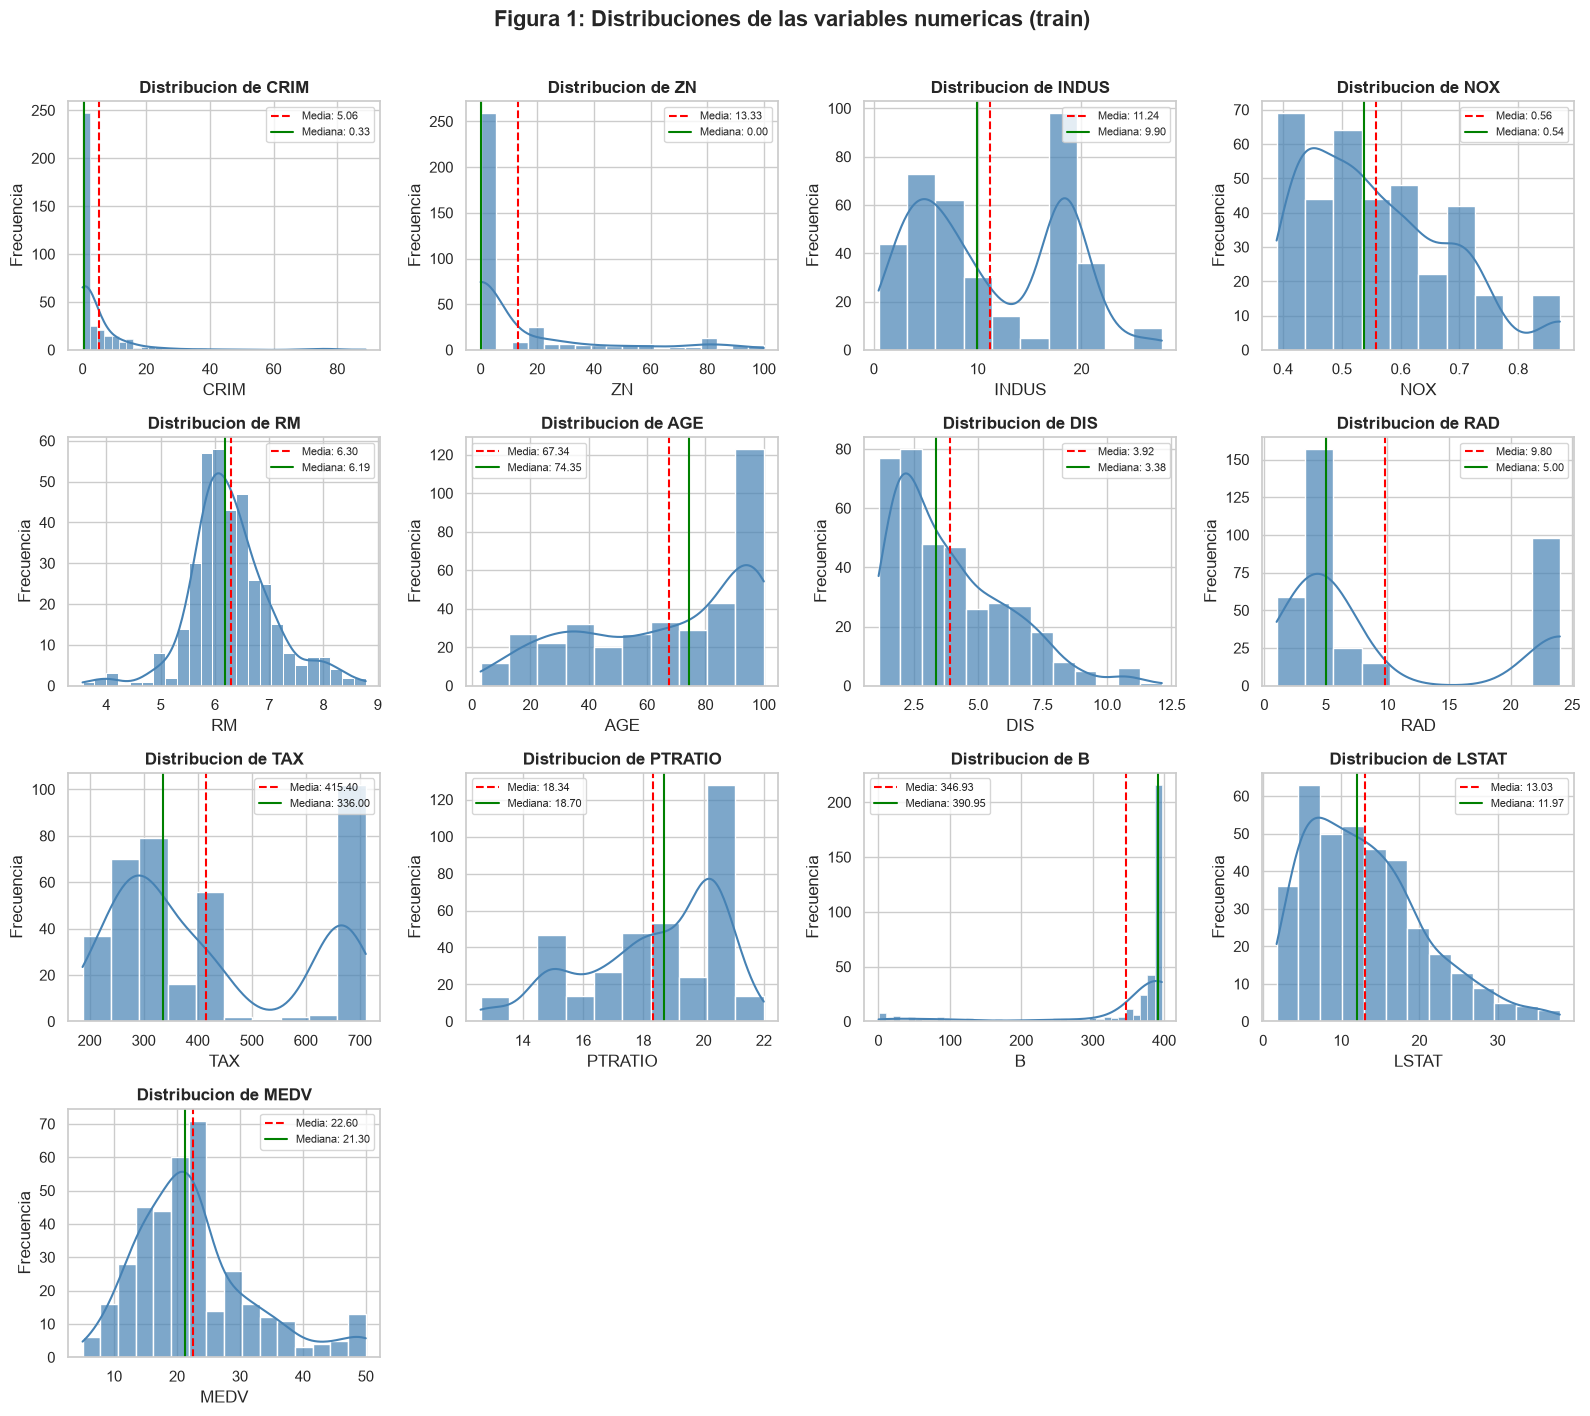

In [10]:
# Figura 1: histogramas de las variables numericas de train con media y mediana (CHAS es binaria, va aparte)
cols_hist = [c for c in data_train.columns if c != 'CHAS']

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_hist):
    ax = axes[i]
    sns.histplot(data_train[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = data_train[col].mean()
    mediana = data_train[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_hist), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figura 1: Distribuciones de las variables numericas (train)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Descripción de cada variable** (rangos y medidas de la tabla de estadísticos; forma según la Figura 1):

| Variable | Qué mide | Rango | Comportamiento |
|---|---|---|---|
| `CRIM` | Criminalidad per cápita | 0,006 – 89 | Casi todos los barrios tienen criminalidad baja (mediana 0,33) y unos pocos, muy alta. Es la más asimétrica. |
| `ZN` | % de terreno para lotes residenciales grandes | 0 – 100 | La mediana es 0: al menos la mitad de los barrios no tiene. Cola larga a la derecha. |
| `INDUS` | % de superficie industrial | 0,46 – 27,7 | Dos grupos: barrios poco industriales y un grupo grande en 18,1. |
| `CHAS` | Limita con el río Charles (1) o no (0) | 0 / 1 | Binaria y desbalanceada: la media 0,07 indica que solo ~7% limita con el río. |
| `NOX` | Óxidos de nitrógeno | 0,39 – 0,87 | Rango chico, leve cola a la derecha. |
| `RM` | Habitaciones promedio por vivienda | 3,6 – 8,8 | Bastante simétrica, centrada en ~6,2. |
| `AGE` | % de viviendas anteriores a 1940 | 2,9 – 100 | Predominan las viviendas viejas (mediana 74%). |
| `DIS` | Distancia a centros de empleo | 1,1 – 12,1 | La mayoría está cerca, con cola a la derecha. |
| `RAD` | Índice de acceso a autopistas | 1 – 24 | Dos grupos: la mayoría entre 1 y 8 y otro grupo grande en 24. |
| `TAX` | Impuesto a la propiedad | 187 – 711 | Dos grupos: uno moderado y otro concentrado en 666. |
| `PTRATIO` | Alumnos por docente | 12,6 – 22 | Cola a la izquierda, con muchos barrios en 20,2. |
| `B` | Índice de composición racial | 0,3 – 396,9 | Casi todos los barrios cerca del máximo y unos pocos con valores bajos. |
| `LSTAT` | % de población de bajo nivel socioeconómico | 1,7 – 38 | Cola a la derecha. |
| **`MEDV`** | **Valor mediano de la vivienda (miles USD)** | 5 – 50 | La mitad de los barrios vale entre 16 y 26. Tiene cola de barrios caros y una acumulación en 50. |

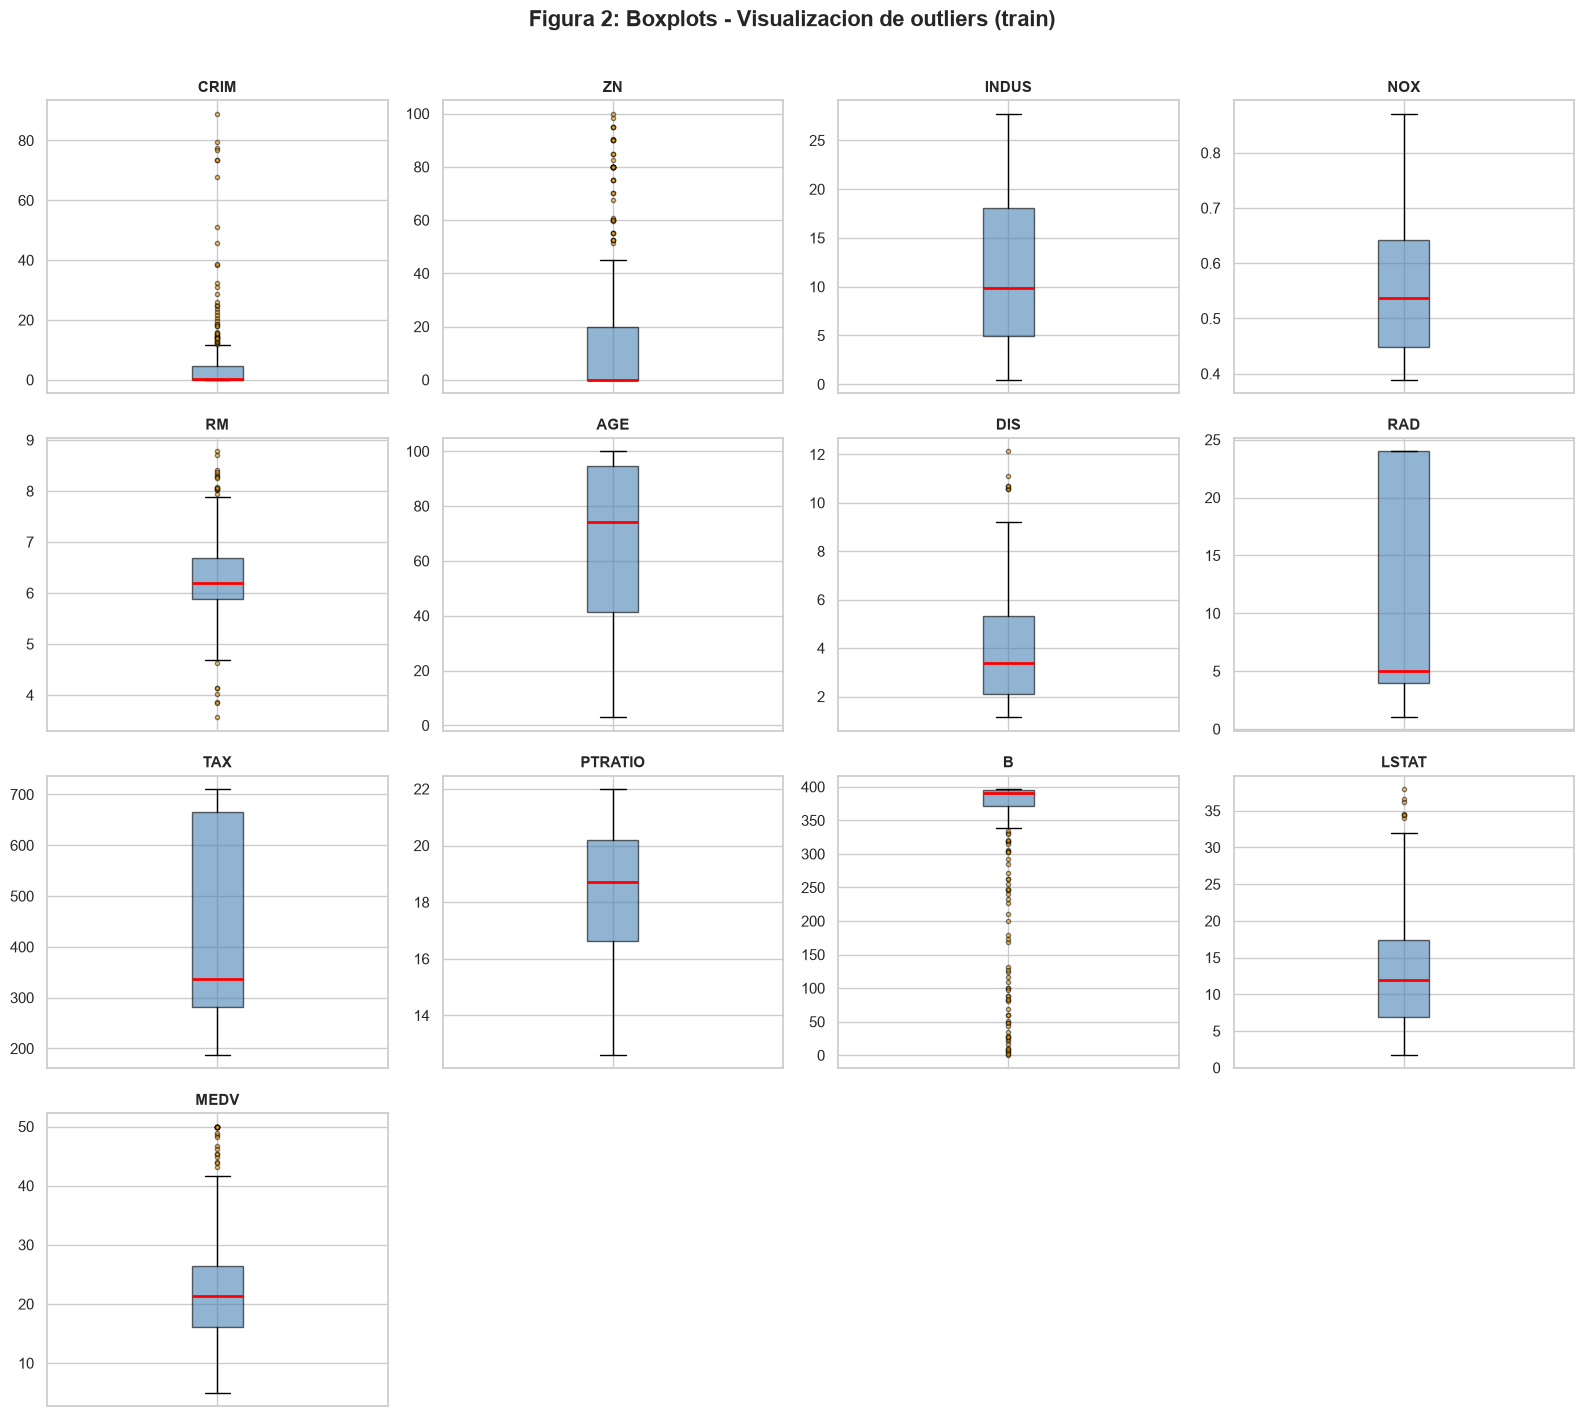

In [11]:
# Figura 2: boxplots de las variables numericas de train
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_hist):
    ax = axes[i]
    datos = data_train[col].dropna()

    # vert=True se omite: es el valor por defecto y el parametro esta deprecado en la version de matplotlib instalada
    ax.boxplot(datos, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange',
                               markersize=3, alpha=0.5))
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_hist), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figura 2: Boxplots - Visualizacion de outliers (train)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# Cantidad y porcentaje de outliers por variable segun el criterio IQR (fuera de Q1 - 1.5*IQR y Q3 + 1.5*IQR)
IQR_FACTOR = 1.5

reporte_outliers = []
for col in cols_hist:
    datos = data_train[col].dropna()
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    outliers_iqr = ((datos < q1 - IQR_FACTOR * iqr) | (datos > q3 + IQR_FACTOR * iqr)).sum()
    reporte_outliers.append({'Variable': col, 'Outliers_IQR': outliers_iqr,
                             'Pct_IQR(%)': outliers_iqr / len(datos) * 100})

pd.DataFrame(reporte_outliers).set_index('Variable').sort_values('Pct_IQR(%)', ascending=False).round(2).T

Variable,B,ZN,CRIM,RM,MEDV,LSTAT,DIS,NOX,INDUS,TAX,RAD,AGE,PTRATIO
Outliers_IQR,64.0000,44.0000,44.0000,22.0000,21.0000,7.0000,7.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Pct_IQR(%),17.4400,12.0500,12.0200,5.9800,5.6100,1.9100,1.8900,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [13]:
# Barrios con MEDV exactamente igual al maximo (50)
print(f'Barrios de train con MEDV = {data_train[TARGET].max()}: {(data_train[TARGET] == data_train[TARGET].max()).sum()}')

Barrios de train con MEDV = 50.0: 10


**Outliers (Figura 2 y tabla):**
- Los que más tienen son `B` (~17%), `CRIM` y `ZN` (~12%), por sus distribuciones muy asimétricas. Son **valores posibles**, no errores: barrios con mucha criminalidad o con todo el terreno para lotes grandes existen.
- **Decisión: se conservan todos.** Eliminarlos limitaría el modelo a barrios "típicos" y superaría el 5% de datos descartados. Esto va a influir en el escalado (sección 10).
- `MEDV` tiene 10 barrios con exactamente 50 (el pico al final de su histograma en la Figura 1). Parece un **tope** en la medición: valen 50 o más. Se conservan, pero el modelo probablemente subestime los barrios más caros.

---
## 7. Relación con el target y correlación

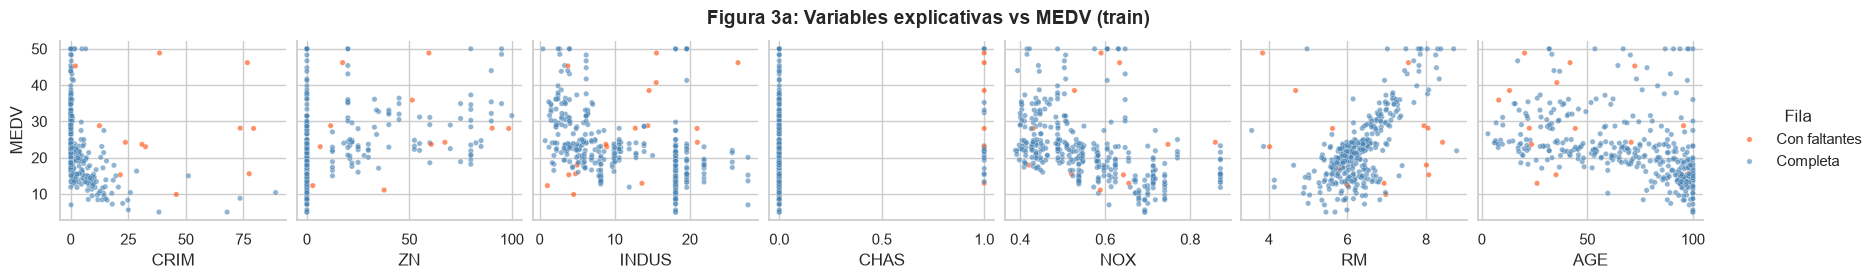

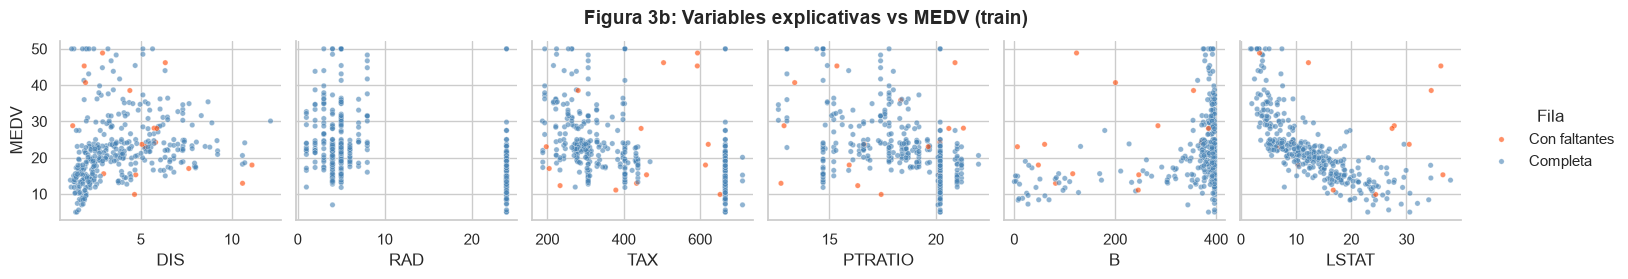

In [14]:
# Figura 3a y 3b: cada variable explicativa contra MEDV, distinguiendo las filas con faltantes
data_plot = data_train.assign(Fila=np.where(filas_con_faltantes, 'Con faltantes', 'Completa'))
paleta = {'Completa': 'steelblue', 'Con faltantes': 'orangered'}

# Se divide en dos graficos para que las 13 variables se lean bien
for parte, x_vars in [('a', cols_features[:7]), ('b', cols_features[7:])]:
    g = sns.pairplot(data_plot, hue='Fila', x_vars=x_vars, y_vars=TARGET,
                     palette=paleta, plot_kws={'alpha': 0.6, 's': 15})
    g.figure.suptitle(f'Figura 3{parte}: Variables explicativas vs MEDV (train)',
                      fontsize=14, fontweight='bold', y=1.08)
    plt.show()

**Figuras 3a y 3b:**
- **`RM`** tiene una relación positiva y casi lineal con el precio. **`LSTAT`**, una relación negativa y **curva**: cae rápido y después se aplana, así que una recta no la captura del todo.
- Las filas con faltantes (naranja) **no siguen el patrón del resto**: aparecen dispersas, con valores que no se corresponden con su precio. Se comportan como **ruido** agregado al dataset.

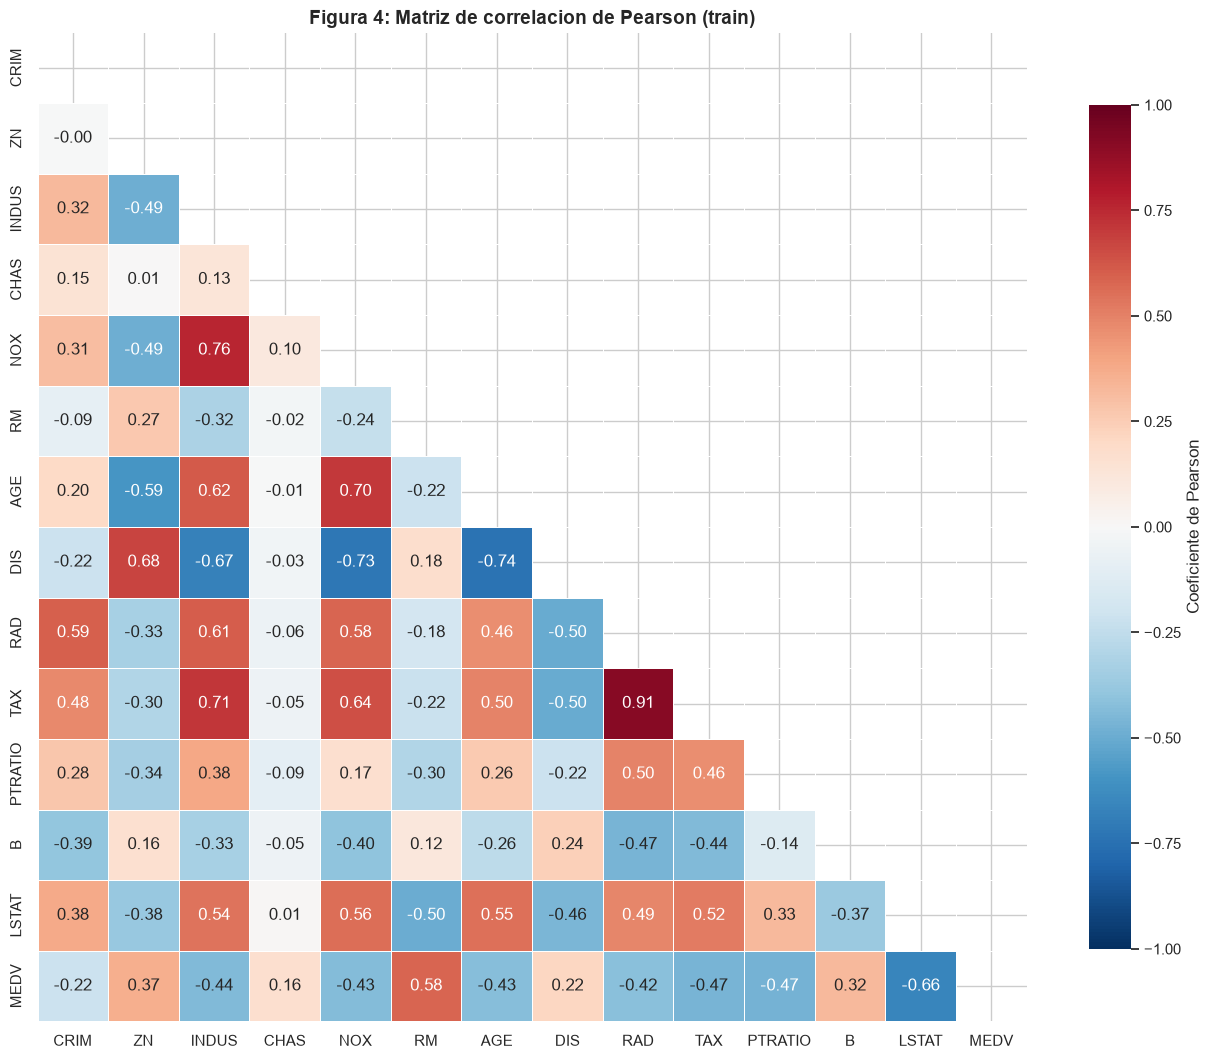

In [15]:
# Figura 4: matriz de correlacion de Pearson con mascara triangular superior
corr_pearson = data_train.corr(method='pearson')
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

# figsize mayor y 2 decimales para que las 14 variables se lean bien
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Figura 4: Matriz de correlacion de Pearson (train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Correlacion de cada variable con MEDV: Pearson (relacion lineal) vs Spearman (relacion monotona, menos sensible a outliers)
corr_spearman = data_train.corr(method='spearman')

corr_target = pd.DataFrame({
    'Pearson': corr_pearson[TARGET].drop(TARGET),
    'Spearman': corr_spearman[TARGET].drop(TARGET)
})
corr_target.sort_values('Spearman', key=abs, ascending=False).round(2).T

,LSTAT,AGE,RM,TAX,NOX,CRIM,INDUS,PTRATIO,ZN,DIS,RAD,B,CHAS
Pearson,-0.6600,-0.4300,0.5800,-0.4700,-0.4300,-0.2200,-0.4400,-0.4700,0.3700,0.2200,-0.4200,0.3200,0.1600
Spearman,-0.8100,-0.5800,0.5700,-0.5700,-0.5600,-0.5500,-0.5200,-0.5100,0.4400,0.4200,-0.3900,0.2400,0.1100


In [17]:
# VIF de cada variable explicativa, sobre las filas de train sin faltantes (LinearRegression no acepta NaN)
df_vif = X_train.dropna()

vif_resultados = []
for col in cols_features:
    X_vif = df_vif.drop(columns=[col]).values  # X_vif / y_vif para no pisar X e y
    y_vif = df_vif[col].values
    r2 = LinearRegression().fit(X_vif, y_vif).score(X_vif, y_vif)
    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False).set_index('Variable')
df_vif_result.round(2).T

Variable,TAX,RAD,INDUS,NOX,DIS,AGE,LSTAT,ZN,PTRATIO,RM,CRIM,B,CHAS
VIF,9.5100,7.6000,4.6000,4.5500,4.2500,3.2200,2.9500,2.4300,1.9000,1.8600,1.6600,1.4200,1.0800


In [18]:
# CHAS es binaria: su correlacion se lee comparando el precio medio de los dos grupos
data_train.groupby('CHAS')[TARGET].agg(['count', 'mean']).round(2).rename(
    columns={'count': 'Barrios', 'mean': 'MEDV medio'}).rename(index={0.0: 'No limita con el rio', 1.0: 'Limita con el rio'})

,Barrios,MEDV medio
CHAS,,
No limita con el rio,342,22.1600
Limita con el rio,24,28.3600


**Correlación (Figura 4, tabla Pearson vs Spearman y VIF):**
- Con el target, las más fuertes son **`LSTAT` (−0,66)** y **`RM` (+0,58)**, seguidas por `PTRATIO`, `TAX`, `INDUS`, `NOX` y `AGE` (entre −0,43 y −0,47). `CHAS` es la más débil (0,16).
- **Pearson vs Spearman:** las dos coinciden en que `LSTAT` y `RM` son las más fuertes. En `CRIM`, `DIS`, `LSTAT`, `AGE` y `NOX`, Spearman es bastante mayor: la relación existe, pero es curva o está afectada por outliers. Un modelo lineal no la aprovecha del todo. Para la matriz usamos Pearson porque el modelo es lineal: la relación que puede usar, y la colinealidad que lo afecta, son las lineales.
- Entre explicativas, el par más alto es **`TAX`–`RAD` (0,88)**, y el VIF lo confirma: `TAX` ≈ 9,5 y `RAD` ≈ 7,6 indican **colinealidad moderada** (por debajo de 10). `INDUS`, `NOX`, `AGE` y `DIS` también están bastante correlacionadas entre sí (|r| ≥ 0,7).
- **Cómo leer las dos variables que no son continuas:**
  - `CHAS` es binaria, así que su correlación no marca una tendencia: es la **diferencia de precio entre los dos grupos** (tabla anterior). No existen valores intermedios entre 0 y 1.
  - `RAD` es un índice ordinal con un salto grande entre 8 y 24, y la correlación supone que todos los saltos valen lo mismo. Hay que tomarla con cuidado, aunque como diagnóstico sirve: Pearson y Spearman dan parecido (−0,38 y −0,35).
- **Decisión: no se elimina ninguna variable.** La colinealidad no es severa, y la regularización (consigna 2) está pensada justamente para manejarla.

---
## 8. Codificación de variables categóricas

No hace falta codificar nada. `CHAS`, la única categórica, ya es una variable 0/1. `RAD` es un índice numérico ordenado y se usa como número.

---
## 9. Imputación de faltantes

Se imputa **después** del análisis, porque el análisis es lo que nos dice cómo hacerlo, y **solo con información de train**.

Usamos **KNN**: para cada barrio con un dato faltante busca los barrios más parecidos según sus otras variables y completa con el promedio de esos vecinos. A diferencia de rellenar con la mediana, aprovecha el resto de la información de la fila. Eso importa sobre todo en las variables con dos grupos (`INDUS`, `RAD`, `TAX`; Figura 1), donde la mediana le pondría a todos los faltantes el mismo valor aunque el barrio pertenezca al otro grupo.

Para elegir la cantidad de vecinos (k) lo medimos: escondemos el 20% de los valores conocidos de cada variable en las filas completas de train, los imputamos y comparamos con el valor real.

In [19]:
# Preparacion: KNN usa distancias, asi que se escala solo para imputar y despues se vuelve a las unidades originales
filas_completas = X_train.dropna()
valores_rad = sorted(filas_completas['RAD'].unique())  # valores validos del indice observados en train

def redondear_discretas(B):
    # KNN promedia vecinos: CHAS tiene que quedar en 0/1 y RAD en un valor valido del indice
    B = B.copy()
    B['CHAS'] = B['CHAS'].round().clip(0, 1)
    B['RAD'] = B['RAD'].apply(lambda v: min(valores_rad, key=lambda r: abs(r - v)))
    return B

def imputar_con_knn(base, k, A):
    escala = StandardScaler().fit(base)
    imputador = KNNImputer(n_neighbors=k).fit(escala.transform(base))
    completado = escala.inverse_transform(imputador.transform(escala.transform(A)))
    return redondear_discretas(pd.DataFrame(completado, columns=cols_features, index=A.index))

In [20]:
# Experimento: se esconde el 20% de los valores conocidos de cada variable y se compara la imputacion con el valor real
idx_escondidos = filas_completas.sample(frac=0.2, random_state=42).index
conocidas = filas_completas.drop(index=idx_escondidos)

resultados_imputacion = {}
for etiqueta, k in [('Mediana/moda', None), ('KNN k=3', 3), ('KNN k=5', 5), ('KNN k=7', 7), ('KNN k=10', 10)]:
    fila = {}
    for col in cols_features:
        verdad = filas_completas.loc[idx_escondidos, col]
        escondidas = filas_completas.copy()
        escondidas.loc[idx_escondidos, col] = np.nan
        if k is None:
            relleno = conocidas[col].mode()[0] if col == 'CHAS' else conocidas[col].median()
            pred = pd.Series(relleno, index=idx_escondidos)
        else:
            pred = imputar_con_knn(conocidas, k, escondidas).loc[idx_escondidos, col]
        # En CHAS (binaria) se mide el porcentaje de aciertos; en el resto, el error RMSE
        fila[col] = (pred == verdad).mean() * 100 if col == 'CHAS' else root_mean_squared_error(verdad, pred)
    resultados_imputacion[etiqueta] = fila

tabla_imputacion = pd.DataFrame(resultados_imputacion).T
tabla_imputacion.round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
Mediana/moda,6.1800,26.0400,8.1000,92.9600,0.1200,0.7600,28.7400,2.0800,9.6800,180.6800,2.3500,116.3100,7.9800
KNN k=3,5.3700,13.0400,3.4600,90.1400,0.0600,0.6000,19.0500,0.9600,4.0800,62.7400,1.7100,96.8600,5.0100
KNN k=5,4.3500,12.5100,4.0000,92.9600,0.0600,0.5700,19.1200,0.8500,1.3800,72.8400,1.7300,85.9800,5.1400
KNN k=7,3.9900,13.6300,4.1000,92.9600,0.0600,0.5400,18.7100,0.8400,2.7800,66.4800,1.7700,82.6300,4.9600
KNN k=10,3.4700,13.7600,4.3100,92.9600,0.0600,0.5600,17.8200,0.8900,2.8900,67.0600,1.8500,83.1000,4.9700


In [21]:
# Resumen: cuanto baja el error de cada version de KNN respecto de imputar con la mediana (variables numericas)
cols_numericas = [c for c in cols_features if c != 'CHAS']
mejoras = {et: (1 - tabla_imputacion.loc[et, cols_numericas] / tabla_imputacion.loc['Mediana/moda', cols_numericas]).mean() * 100
           for et in ['KNN k=3', 'KNN k=5', 'KNN k=7', 'KNN k=10']}
pd.DataFrame({'Mejora promedio sobre la mediana (%)': mejoras}).round(1).T

,KNN k=3,KNN k=5,KNN k=7,KNN k=10
Mejora promedio sobre la mediana (%),40.6000,44.5000,44.2000,44.1000


**Decisión: KNN con 5 vecinos.** Imputa mejor que la mediana en todas las variables numéricas, y a partir de k = 5 la mejora deja de crecer. En `CHAS` acierta lo mismo que la moda, porque el 93% de los barrios no limita con el río: no gana nada, pero tampoco pierde, y así usamos un único método para todas las variables.

In [22]:
# Imputacion definitiva: KNN con 5 vecinos ajustado solo con train y aplicado a los tres conjuntos
K_VECINOS = 5
escala_imputacion = StandardScaler().fit(X_train)
imputador = KNNImputer(n_neighbors=K_VECINOS).fit(escala_imputacion.transform(X_train))

def imputar(A):
    completado = escala_imputacion.inverse_transform(imputador.transform(escala_imputacion.transform(A)))
    return redondear_discretas(pd.DataFrame(completado, columns=cols_features, index=A.index))

X_train_imp, X_val_imp, X_test_imp = imputar(X_train), imputar(X_val), imputar(X_test)

pd.DataFrame({
    'Valores imputados': [X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum()],
    'Faltantes despues': [X_train_imp.isna().sum().sum(), X_val_imp.isna().sum().sum(), X_test_imp.isna().sum().sum()],
}, index=['Train', 'Validacion', 'Test'])

,Valores imputados,Faltantes despues
Train,97,0
Validacion,5,0
Test,30,0


In [23]:
# Control: valores asignados a las variables discretas en las filas imputadas de train
print(f'RAD imputado: {sorted(X_train_imp.loc[X_train["RAD"].isna(), "RAD"].unique().tolist())}')
print(f'CHAS imputado: {sorted(X_train_imp.loc[X_train["CHAS"].isna(), "CHAS"].unique().tolist())}')

RAD imputado: [4.0, 5.0, 6.0, 8.0, 24.0]
CHAS imputado: [0.0, 1.0]


No quedan faltantes, y las dos variables discretas recibieron valores válidos: `RAD` valores del índice y `CHAS` solo 0 o 1.

---
## 10. Escalado

Las variables tienen escalas muy distintas (`NOX` está por debajo de 1 y `TAX` en cientos; ver la tabla de estadísticos). El descenso del gradiente y la regularización de las secciones siguientes necesitan que sean comparables.

Comparamos dos opciones: **estandarizar** (restar la media y dividir por el desvío) o **escalar de forma robusta** (mediana e IQR), que era la candidata por la cantidad de outliers que decidimos conservar.

In [24]:
# Comparacion de escaladores: ¿cambia el ajuste del modelo lineal? ¿que tan grandes quedan los valores?
comparacion_escalado = []
for nombre, escalador in [('StandardScaler', StandardScaler()), ('RobustScaler', RobustScaler())]:
    A = escalador.fit_transform(X_train_imp)
    V = escalador.transform(X_val_imp)
    lineal = LinearRegression().fit(A, y_train)
    comparacion_escalado.append({'Escalador': nombre,
                                 'R2 train': lineal.score(A, y_train),
                                 'R2 validacion': r2_score(y_val, lineal.predict(V)),
                                 'Valor escalado mas extremo': np.abs(A).max()})

pd.DataFrame(comparacion_escalado).set_index('Escalador').round(3)

,R2 train,R2 validacion,Valor escalado mas extremo
Escalador,,,
StandardScaler,0.6600,0.6080,6.8460
RobustScaler,0.6600,0.6080,18.4220


**El ajuste es el mismo con los dos.** Escalar multiplica cada variable por una constante, y la regresión lineal lo compensa dividiendo su coeficiente por esa misma constante, así que la predicción no cambia.

La diferencia está en el **tamaño de los valores escalados**. El escalado robusto divide por el IQR, que en las variables muy asimétricas es chico, y deja los outliers en valores mucho más grandes. Eso agranda los pasos del descenso del gradiente y lo vuelve inestable.

**Decisión: `StandardScaler`.** Con el mismo ajuste, hace que el descenso del gradiente converja de forma estable. Se ajusta con train y se aplica a validación y test; el target no se escala.

In [25]:
# Escalado final: fit solo con train, transform en validacion y test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Verificacion: en train cada variable queda con media 0 y desvio 1
escalado = pd.DataFrame(X_train_scaled, columns=cols_features)
pd.DataFrame({'Media': escalado.mean(), 'Desvio': escalado.std()}).round(2).T

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
Media,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000
Desvio,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
